# Edu-ca-te Analysis & Recommendation
**Beacon Innovation Hub — Data Department Foundational Competence Challenge**

This notebook uses the cleaned datasets (produced by `01_data_cleaning.ipynb`) to answer the
core business question: **which subject should receive additional tutoring resources next
term, and why?**

It covers: engagement by subject, the relationship between engagement and mark change,
enquiry demand and conversion, tutoring capacity pressure, a small set of decision-relevant
KPIs, a management-facing visualization, and a final recommendation with trade-offs and
limitations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

learners = pd.read_csv("../data/cleaned/learners_clean.csv")
engagement = pd.read_csv("../data/cleaned/engagement_clean.csv")
assessments = pd.read_csv("../data/cleaned/assessments_clean.csv")
capacity = pd.read_csv("../data/cleaned/support_capacity_clean.csv")
enquiries = pd.read_csv("../data/cleaned/enquiries_clean.csv")

print("learners:", len(learners), "| engagement:", len(engagement), "| assessments:", len(assessments))
print("support_capacity:", len(capacity), "| enquiries:", len(enquiries))


learners: 148 | engagement: 183 | assessments: 193
support_capacity: 4 | enquiries: 121


## 1. Engagement by Subject

Learner participation, attendance, and video engagement, summarized per subject.


In [2]:
eng_by_subj = engagement.groupby("subject").agg(
    learners_engaged=("learner_id", "nunique"),
    avg_attendance_pct=("tutoring_attendance_pct", "mean"),
    avg_videos_watched=("videos_watched", "mean"),
    avg_watch_time_min=("watch_time_minutes", "mean"),
).round(1)
eng_by_subj


,learners_engaged,avg_attendance_pct,avg_videos_watched,avg_watch_time_min
subject,,,,
Accounting,29,74.2,19.2,307.9
Life Sciences,34,75.1,20.1,350.7
Mathematics,63,72.8,20.9,353.1
Physical Sciences,57,78.0,18.0,339.3


**Reading:** Mathematics has by far the largest engaged population (63 learners), consistent
with it being a compulsory/near-universal subject. Physical Sciences shows the highest average
attendance (78%) despite a large learner base. Accounting has the smallest engaged population
(29) but comparable attendance to the other subjects — participation levels alone don't point
to a clear "neediest" subject; they need to be read alongside outcomes and capacity.


## 2. Assessment Performance by Subject

Baseline vs. latest marks, and the resulting mark change. Note: `mark_change` is only
computed where both `baseline_mark` and `latest_mark` survived cleaning (i.e. are within
0–100) — this is why `n_with_valid_change` is slightly lower than the number of learners
assessed for each subject.


In [3]:
ass_by_subj = assessments.groupby("subject").agg(
    learners_assessed=("learner_id", "nunique"),
    avg_baseline_mark=("baseline_mark", "mean"),
    avg_latest_mark=("latest_mark", "mean"),
    avg_mark_change=("mark_change", "mean"),
    n_with_valid_change=("mark_change", "count"),
).round(1)
ass_by_subj


,learners_assessed,avg_baseline_mark,avg_latest_mark,avg_mark_change,n_with_valid_change
subject,,,,,
Accounting,29,56.1,71.7,16.5,26
Life Sciences,34,56.2,73.5,18.1,30
Mathematics,65,52.5,68.6,15.6,62
Physical Sciences,56,52.8,67.2,14.1,52


**Reading:** Life Sciences shows the strongest average mark improvement (+18.1), followed by
Accounting (+16.5) and Mathematics (+15.6). **Physical Sciences shows the weakest average
improvement (+14.1)** — notable because it also has the highest attendance rate of any
subject. High engagement is not automatically translating into the largest mark gains there.


## 3. Does Engagement Relate to Mark Change?

We check whether attendance, videos watched, or watch time are **associated** with mark
change — this is a correlation check, not a causal claim. Learners who attend more or watch
more videos might simply be more motivated overall, which could independently explain better
marks (a confound), rather than the engagement itself causing the improvement.


In [4]:
merged = engagement.merge(assessments, on=["learner_id", "subject"], how="inner")

corr_table = merged[["tutoring_attendance_pct", "videos_watched", "watch_time_minutes", "mark_change"]].corr()["mark_change"].drop("mark_change")
corr_table.round(3)


tutoring_attendance_pct   -0.042
videos_watched             0.826
watch_time_minutes         0.798
Name: mark_change, dtype: float64

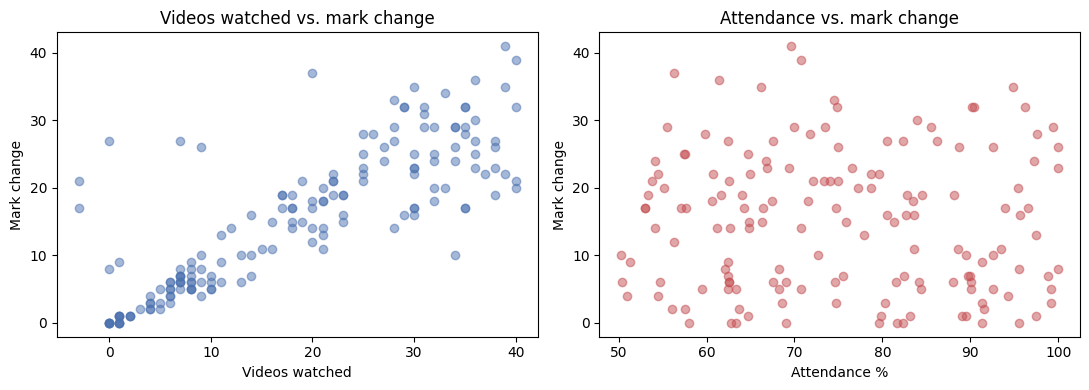

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(merged["videos_watched"], merged["mark_change"], alpha=0.5, color="#4C72B0")
axes[0].set_xlabel("Videos watched")
axes[0].set_ylabel("Mark change")
axes[0].set_title("Videos watched vs. mark change")

axes[1].scatter(merged["tutoring_attendance_pct"], merged["mark_change"], alpha=0.5, color="#C44E52")
axes[1].set_xlabel("Attendance %")
axes[1].set_ylabel("Mark change")
axes[1].set_title("Attendance vs. mark change")

plt.tight_layout()
plt.savefig("../outputs/charts/engagement_vs_mark_change.png", dpi=150)
plt.show()


**Reading:** `videos_watched` (r ≈ 0.83) and `watch_time_minutes` (r ≈ 0.80) show a strong
positive **association** with mark change — learners who watched more videos or spent more
time watching tended to show larger mark improvements. `tutoring_attendance_pct` shows
essentially **no association** (r ≈ -0.04) with mark change.

**Important caveat — association, not causation:** this pattern is consistent with video
engagement *contributing* to improvement, but it's equally consistent with more motivated or
more academically engaged learners simply doing both (watching more videos *and* improving
more) for reasons unrelated to the videos themselves. We cannot distinguish these explanations
with this data. The near-zero attendance correlation is worth flagging on its own — it
suggests that simply showing up to a tutoring session, without engaging with the video
material, is not obviously linked to better outcomes here, though other unmeasured factors
(e.g. quality of a given session) could also explain this.


## 4. Enquiry Demand and Conversion by Subject

Prospective demand (enquiries), and what share of that demand converts to actual
registration. Enquiries marked `Maybe` or `Unknown` are excluded from the conversion-rate
calculation (rather than assumed to be a No), since forcing them into a category would
overstate precision the data doesn't support.


In [6]:
enq_by_subj = enquiries.groupby("subject").agg(
    total_enquiries=("enquiry_id", "count"),
    converted_yes=("converted_to_registration", lambda s: (s == "Yes").sum()),
    converted_no=("converted_to_registration", lambda s: (s == "No").sum()),
    maybe_or_unknown=("converted_to_registration", lambda s: s.isin(["Maybe", "Unknown"]).sum()),
)
enq_by_subj["conversion_rate_pct"] = (
    enq_by_subj["converted_yes"] / (enq_by_subj["converted_yes"] + enq_by_subj["converted_no"]) * 100
).round(1)
enq_by_subj


,total_enquiries,converted_yes,converted_no,maybe_or_unknown,conversion_rate_pct
subject,,,,,
Accounting,12,6,6,0,50.0
Life Sciences,15,5,10,0,33.3
Mathematics,51,24,25,2,49.0
Physical Sciences,43,20,23,0,46.5


**Reading:** Mathematics generates by far the most raw enquiry volume (51), but its
conversion rate (49.0%) is roughly in line with Accounting (50.0%) and Physical Sciences
(46.5%). **Life Sciences stands out with the lowest conversion rate (33.3%)** despite decent
demand (15 enquiries) — prospective learners are enquiring about Life Sciences but converting
to registration less often than for any other subject. This is a different signal from raw
enquiry volume, and is exactly the kind of divergence the brief warns about: a subject with
strong demand may have weak conversion.


## 5. Tutoring Capacity Pressure

Comparing current capacity (active tutors, weekly hours) against demand signals (currently
engaged learners, waiting list) to see where the strain is greatest.


In [7]:
kpi = eng_by_subj.join(
    ass_by_subj[["avg_mark_change", "n_with_valid_change"]]
).join(
    enq_by_subj[["total_enquiries", "conversion_rate_pct"]]
).join(
    capacity.set_index("subject")
)

kpi["learners_per_tutor"] = (kpi["learners_engaged"] / kpi["active_tutors"]).round(1)
kpi["waiting_list_per_tutor"] = (kpi["waiting_list"] / kpi["active_tutors"]).round(1)
kpi["waiting_list_pct_of_engaged"] = (kpi["waiting_list"] / kpi["learners_engaged"] * 100).round(1)

kpi


,learners_engaged,avg_attendance_pct,avg_videos_watched,avg_watch_time_min,avg_mark_change,n_with_valid_change,total_enquiries,conversion_rate_pct,active_tutors,weekly_tutor_hours,waiting_list,estimated_cost_per_extra_hour,learners_per_tutor,waiting_list_per_tutor,waiting_list_pct_of_engaged
subject,,,,,,,,,,,,,,,
Accounting,29,74.2,19.2,307.9,16.5,26,12,50.0,2,15.0,19.0,175.0,14.5,9.5,65.5
Life Sciences,34,75.1,20.1,350.7,18.1,30,15,33.3,3,22.0,14.0,165.0,11.3,4.7,41.2
Mathematics,63,72.8,20.9,353.1,15.6,62,51,49.0,4,26.0,31.0,180.0,15.8,7.8,49.2
Physical Sciences,57,78.0,18.0,339.3,14.1,52,43,46.5,3,18.0,28.0,210.0,19.0,9.3,49.1


**Reading:** Two capacity-pressure measures tell a consistent story:
- **`waiting_list_per_tutor`** — Accounting (9.5) and Physical Sciences (9.3) are both under
  significantly more pressure per tutor than Life Sciences (4.7) or Mathematics (7.8).
- **`waiting_list_pct_of_engaged`** — Accounting stands out clearly here: its waiting list
  (19) is **65.5%** the size of its entire currently-engaged learner population — by far the
  highest ratio of any subject. In other words, for every ~3 learners Accounting currently
  serves, roughly 2 more are waiting. No other subject comes close to this proportion.

Accounting has the smallest tutor team (2) and the fewest weekly hours (15) of any subject,
which is consistent with this being the most capacity-constrained subject relative to its own
demand, even though it isn't the largest subject in absolute terms.


## 6. Decision-Relevant KPIs — Summary

A focused set of KPIs, each chosen because it maps directly onto a signal the brief asks for
(participation, outcome, demand, conversion, or capacity strain) — not an arbitrary composite
score.

| KPI | What it captures | Why it belongs in this decision |
|---|---|---|
| `avg_attendance_pct` | Current participation level | Baseline engagement — low participation could mean resources wouldn't be used even if added |
| `avg_mark_change` | Average learner improvement | Whether the service is delivering results for learners already being tutored |
| `total_enquiries` / `conversion_rate_pct` | Prospective demand and how much of it becomes real registration | Distinguishes subjects with real, convertible demand from subjects with interest that doesn't translate into learners |
| `waiting_list_pct_of_engaged` | Unmet demand relative to who's already being served | The clearest single measure of *relative* capacity strain — a large waiting list means little if the subject already serves a huge population; this normalizes for subject size |
| `estimated_cost_per_extra_hour` | Cost of expanding capacity | Ensures the recommendation accounts for the practical cost of the decision, not just need |


## 7. Management-Facing Visualization


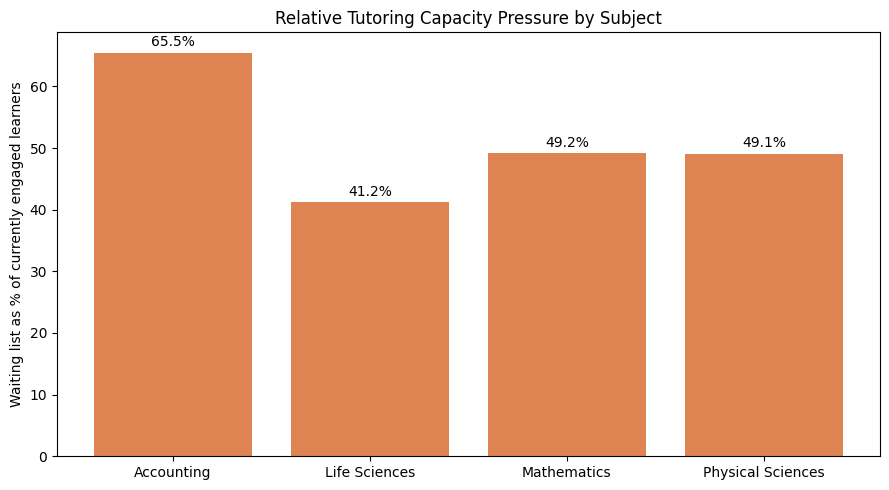

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
subjects = kpi.index.tolist()
x = range(len(subjects))

bars = ax.bar(x, kpi["waiting_list_pct_of_engaged"], color="#DD8452")
ax.set_xticks(list(x))
ax.set_xticklabels(subjects)
ax.set_ylabel("Waiting list as % of currently engaged learners")
ax.set_title("Relative Tutoring Capacity Pressure by Subject")

for i, v in enumerate(kpi["waiting_list_pct_of_engaged"]):
    ax.text(i, v + 1, f"{v}%", ha="center")

plt.tight_layout()
plt.savefig("../outputs/charts/capacity_pressure_by_subject.png", dpi=150)
plt.show()


## 8. Recommendation

**Recommended subject for additional tutoring resources next term: Accounting.**

**Supporting evidence:**
- **Capacity strain is proportionally highest in Accounting.** Its waiting list equals 65.5%
  of its currently-engaged learner population — no other subject is above 50%. It also has
  the fewest active tutors (2) and fewest weekly tutoring hours (15) of any subject, so it has
  the least room to absorb its existing waiting list without new resources.
- **The tutoring already happening in Accounting is working.** Average mark change (+16.5) is
  the second-highest of the four subjects, and conversion rate (50.0%) is the highest — so
  additional capacity would be extending a service that demonstrably converts interest into
  registration and delivers real improvement, not propping up a subject that isn't performing.
- **Cost of expansion is comparatively reasonable.** At R175/hour, Accounting is the
  second-cheapest subject to expand (only Life Sciences is cheaper, at R165/hour).

**Trade-offs and the case for an alternative:**
- **Mathematics** has by far the largest absolute learner base and enquiry volume (51
  enquiries, 63 engaged learners), and a management team focused purely on scale — the most
  learners reached per rand spent — could reasonably prioritize it instead. We did not
  recommend it because its capacity ratios (`waiting_list_per_tutor` = 7.8) are less strained
  than Accounting's, suggesting its larger existing team is coping comparatively better.
- **Physical Sciences** has the weakest average mark improvement (+14.1) despite the highest
  attendance (78%) — a case could be made that this subject needs help converting engagement
  into results. We weighted this less heavily because it is also the most expensive subject to
  expand (R210/hour) and we cannot determine from this data whether the underperformance is a
  capacity issue at all, versus a curriculum-difficulty or teaching-quality issue that more
  tutoring hours wouldn't necessarily fix.
- **Life Sciences** has the strongest average mark improvement (+18.1) but the weakest
  conversion rate (33.3%) — its problem looks more like a marketing/enrolment issue than a
  tutoring-capacity issue, so additional tutoring hours are unlikely to be the right lever.

## 9. Limitations

- **Correlation vs. causation:** the engagement–mark-change relationship (Section 3) is an
  association only. We cannot rule out that more motivated learners simply engage more and
  also improve more, independent of the engagement itself.
- **Excluded/uncertain records:** 29 rows across `learners`, `engagement`, and `assessments`
  were excluded from this analysis due to unresolvable data-quality issues (orphaned IDs,
  missing keys) — see `outputs/excluded_flagged_records.csv`. If these represent a
  disproportionate share of any one subject, the picture for that subject could shift.
- **Implausible marks treated as missing:** 11 `latest_mark` values (repeated 1050s and 180s)
  were set to missing rather than corrected, since the true value could not be reconstructed
  with confidence. If these were genuine data-entry slips of a knowable kind (e.g. a stray
  trailing zero), the true averages could differ slightly from what's shown here.
- **"Sci" subject mapping assumption:** engagement/assessment rows labelled `"Sci"` were
  mapped to Physical Sciences on the assumption that no separate general-science subject
  exists in this platform (see cleaning log). If that assumption is wrong, Physical Sciences'
  numbers in this analysis would be slightly overstated.
- **Small samples for Accounting and Life Sciences:** with 29 and 34 engaged learners
  respectively (versus 57–63 for the other two subjects), their averages are more sensitive to
  individual outliers than the larger subjects' figures.
- **No causal capacity model:** we cannot directly measure how much a specific increase in
  tutor hours would reduce the waiting list or lift marks in Accounting — the recommendation
  is based on relative need and demonstrated effectiveness, not a projected return on
  investment.

## 10. What Additional Data Edu-ca-te Should Collect

- **A stable, validated learner ID system** at the point of data entry (e.g. dropdown/lookup
  rather than free text) to eliminate the case/whitespace and orphaned-ID issues seen here.
- **Session-level tutoring records** (which specific sessions a learner attended, and with
  which tutor) rather than only an aggregate attendance percentage — this would let Edu-ca-te
  test whether specific tutors or session formats drive the mark improvement, rather than
  relying on a blunt attendance metric that showed no association with outcomes here.
- **A consistent, single-choice conversion field** for enquiries (not six different
  encodings) captured at the point of enquiry, with a defined process for following up
  "Maybe" responses so they don't remain permanently ambiguous.
- **Reason for waiting-list status** (e.g. no tutor availability vs. scheduling conflict vs.
  cost) — this would let Edu-ca-te distinguish a true capacity shortage from other blockers to
  registration.
- **A pre/post assessment on a common, standardized scale** across subjects, ideally with a
  fixed assessment date rather than an open-ended "latest," so mark-change comparisons across
  subjects are on equal footing.
